In [2]:
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
from plot_pca import plot_pca_loadings
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime

from scipy.signal import welch
import pandas as pd
from fooof import FOOOF, FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fm, get_band_peak_fg

/tmp/ipykernel_928420/2426869506.py:22: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF, FOOOFGroup


In [67]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests


def compute_mixedlm_r2(result, model):
    fixed_effects_pred = model.exog @ result.fe_params
    var_fixed = np.var(fixed_effects_pred, ddof=1)
    var_random = result.cov_re.iloc[0, 0] if hasattr(result.cov_re, 'iloc') else result.cov_re[0][0]
    var_resid = result.scale
    r2_marginal = var_fixed / (var_fixed + var_random + var_resid)
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)
    return r2_marginal, r2_conditional


def glm_exponent(df, roi_kept, reml=False):
    results_summary = []

    for roi in roi_kept:
        records_kept = df[(df['roi'] == roi) & (df['r2'] >= 0.9)].copy()

        records_kept['exponent_z'] = (
            records_kept.groupby('ptID')['exponent']
            .transform(lambda x: (x - x.mean()) / x.std())
        )

        row = {'roi': roi, 'n': len(records_kept)}

        # ---------------- 3 models with RAW exponent ----------------
        # model_sens = smf.mixedlm("exponent ~ sensory", data=records_kept, groups=records_kept["ptID"])
        model_sens = smf.mixedlm("sensory ~ exponent", data=records_kept, groups=records_kept["ptID"])
        result_sens = model_sens.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        r2_m, r2_c = compute_mixedlm_r2(result_sens, model_sens)
        contrast = result_sens.t_test(np.array([[0, 1]]))
        row.update({
            'beta_sensory_raw': result_sens.params['exponent'], 'p_sensory_raw': contrast.pvalue,
            'r2_marginal_sens_raw': r2_m, 'r2_conditional_sens_raw': r2_c
        })

        # model_aff = smf.mixedlm("exponent ~ affective", data=records_kept, groups=records_kept["ptID"])
        model_aff = smf.mixedlm("affective ~ exponent", data=records_kept, groups=records_kept["ptID"])
        result_aff = model_aff.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        r2_m, r2_c = compute_mixedlm_r2(result_aff, model_aff)
        contrast = result_aff.t_test(np.array([[0, 1]]))
        row.update({
            'beta_affect_raw': result_aff.params['exponent'], 'p_affect_raw': contrast.pvalue,
            'r2_marginal_aff_raw': r2_m, 'r2_conditional_aff_raw': r2_c
        })

        # model_both = smf.mixedlm("exponent ~ affective + sensory", data=records_kept, groups=records_kept["ptID"])
        # result_both = model_both.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        # r2_m, r2_c = compute_mixedlm_r2(result_both, model_both)
        # contrast = result_both.t_test(np.array([[0, 1, -1]]))
        # row.update({
        #     'beta_sensory_both_raw': result_both.params['sensory'],
        #     'beta_affect_both_raw': result_both.params['affective'],
        #     'p_difference_both_raw': contrast.pvalue,
        #     'r2_marginal_both_raw': r2_m, 'r2_conditional_both_raw': r2_c
        # })

        # ---------------- 3 models with Z-SCORED exponent ----------------
        # model_sens_z = smf.mixedlm("exponent_z ~ sensory", data=records_kept, groups=records_kept["ptID"])
        model_sens_z = smf.mixedlm("sensory ~ exponent_z", data=records_kept, groups=records_kept["ptID"])
        result_sens_z = model_sens_z.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        r2_m, r2_c = compute_mixedlm_r2(result_sens_z, model_sens_z)
        contrast = result_sens_z.t_test(np.array([[0, 1]]))
        row.update({
            'beta_sensory_z': result_sens_z.params['exponent_z'], 'p_sensory_z': contrast.pvalue,
            'r2_marginal_sens_z': r2_m, 'r2_conditional_sens_z': r2_c
        })

        # model_aff_z = smf.mixedlm("exponent_z ~ affective", data=records_kept, groups=records_kept["ptID"])
        model_aff_z = smf.mixedlm("affective ~ exponent_z", data=records_kept, groups=records_kept["ptID"])
        result_aff_z = model_aff_z.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        r2_m, r2_c = compute_mixedlm_r2(result_aff_z, model_aff_z)
        contrast = result_aff_z.t_test(np.array([[0, 1]]))
        row.update({
            'beta_affect_z': result_aff_z.params['exponent_z'], 'p_affect_z': contrast.pvalue,
            'r2_marginal_aff_z': r2_m, 'r2_conditional_aff_z': r2_c
        })

        # model_both_z = smf.mixedlm("exponent_z ~ affective + sensory", data=records_kept, groups=records_kept["ptID"])
        # result_both_z = model_both_z.fit(method=["lbfgs"], reml=reml, maxiter=1000)
        # r2_m, r2_c = compute_mixedlm_r2(result_both_z, model_both_z)
        # contrast = result_both_z.t_test(np.array([[0, 1, -1]]))
        # row.update({
        #     'beta_sensory_both_z': result_both_z.params['sensory'],
        #     'beta_affect_both_z': result_both_z.params['affective'],
        #     'p_difference_both_z': contrast.pvalue,
        #     'r2_marginal_both_z': r2_m, 'r2_conditional_both_z': r2_c
        # })

        results_summary.append(row)

    results_df = pd.DataFrame(results_summary)

    for pcol in ['p_sensory_raw', 'p_affect_raw', 
                #  'p_difference_both_raw',
                 'p_sensory_z', 'p_affect_z'
                #  , 'p_difference_both_z'
                 ]:
        _, p_fdr, _, _ = multipletests(results_df[pcol], method='fdr_bh')
        results_df[f'{pcol}_fdr'] = p_fdr

    return results_df

In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']

all_records = []
for ptID in ptIDs:
    print(ptID)
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['ptID'] = ptID
    # records_kept = records_df[(records_df['r2'] >= 0.9)].copy()

    # records_kept['exponent_z'] = (
    #     records_kept['exponent']
    #     .transform(lambda x: (x - x.mean()) / x.std())
    # )
    # all_records.append(records_kept)
    all_records.append(records_df)
    # rois = sorted(records_df['roi'].unique())

all_records_pd = pd.concat(all_records, ignore_index=True)

RCS02
RCS03
RCS04
RCS05
RCS06
RCS07
RCS08
RCS09


In [ ]:
roi_kept_alt = sorted([roi for roi in all_records_pd['roi'].unique() if roi!='R ACC'])
final_summary = glm_exponent(all_records_pd,roi_kept_alt)

In [69]:
final_summary_1 = final_summary.sort_values('roi')
final_summary_1

,roi,n,beta_sensory_raw,p_sensory_raw,r2_marginal_sens_raw,r2_conditional_sens_raw,beta_affect_raw,p_affect_raw,r2_marginal_aff_raw,r2_conditional_aff_raw,...,r2_marginal_sens_z,r2_conditional_sens_z,beta_affect_z,p_affect_z,r2_marginal_aff_z,r2_conditional_aff_z,p_sensory_raw_fdr,p_affect_raw_fdr,p_sensory_z_fdr,p_affect_z_fdr
0,L ACC,716,0.544161,0.00509460081752937,0.011208,0.011208,0.333841,0.04334135370460245,0.005863,0.005863,...,0.008815,0.008815,0.087825,0.08237658050166329,0.004202,0.004202,0.007446,0.05882,0.018496,0.104344
1,L AINS,1493,0.106739,0.3370792987769361,0.000610,0.000651,0.129904,0.18532830137803225,0.001506,0.001506,...,0.000792,0.000792,0.047224,0.1265449797845603,0.001562,0.001562,0.376736,0.220077,0.309552,0.150272
2,L Caudate,1483,0.009860,0.9140940685510097,0.000008,0.000008,0.036701,0.5898193621651671,0.000206,0.000206,...,0.000037,0.000037,0.023248,0.4576608428100132,0.000372,0.000372,0.914094,0.622587,0.860893,0.483086
3,L IC,2405,0.138180,0.03009026096781745,0.002591,0.002591,0.131286,0.00532285426882617,0.004271,0.004271,...,0.001686,0.001686,0.065106,0.0053243080752132365,0.003220,0.003220,0.038114,0.008428,0.055636,0.009197
4,L MCC,1204,0.616138,4.708477649693642e-10,0.065487,0.065487,0.354254,1.8785798182041518e-06,0.039415,0.039415,...,0.024074,0.024074,0.151338,4.867829323562112e-06,0.017067,0.017067,0.0,0.000012,0.0,0.000092
5,L OFC,1847,-0.507063,0.004650621031718879,0.006011,0.006011,-0.206985,0.060676820168391085,0.002650,0.002650,...,0.005905,0.005905,-0.062523,0.008491951021805506,0.003738,0.003738,0.007363,0.076857,0.00294,0.013446
6,L PINS,1480,0.494067,0.0027759250125536333,0.008776,0.008776,0.485550,0.00021394309851411776,0.013377,0.013377,...,0.004466,0.004466,0.111826,0.0003569905644079545,0.008544,0.008544,0.004795,0.000677,0.017275,0.00113
7,L THAL,2183,0.263160,0.000507776297920884,0.006507,0.006507,0.182353,0.0014248078291884674,0.005483,0.005483,...,0.004562,0.004562,0.072475,0.0034708816138257076,0.003899,0.003899,0.001206,0.002707,0.00425,0.007327
8,L dlPFC,2186,0.617229,8.631344050576182e-12,0.027379,0.027379,0.328938,1.7199271850466203e-05,0.011034,0.011034,...,0.019739,0.019739,0.118203,1.7653847985068674e-05,0.008363,0.008363,0.0,0.000082,0.0,0.000168
9,L dmPFC,970,0.365069,0.0022963441429269733,0.018804,0.018804,0.368733,0.00014781301704410772,0.028830,0.028830,...,0.009881,0.009881,0.147180,0.00011966897911040687,0.015042,0.015042,0.004363,0.000562,0.004448,0.000455


Text(0.5, 1.0, 'Random-effect contribution differs by ROI and affective/sensory pain, raw exponent')

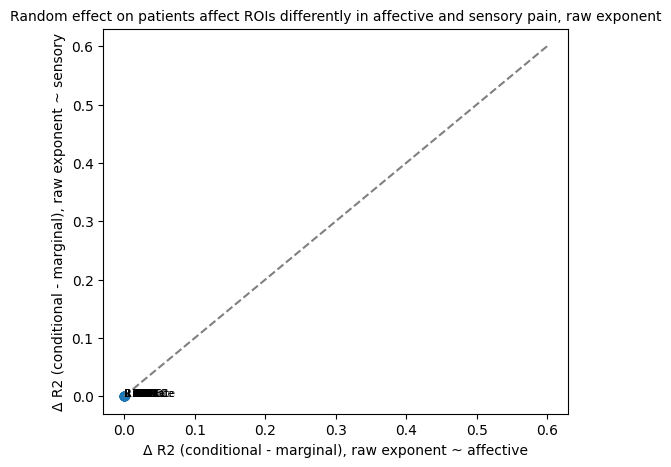

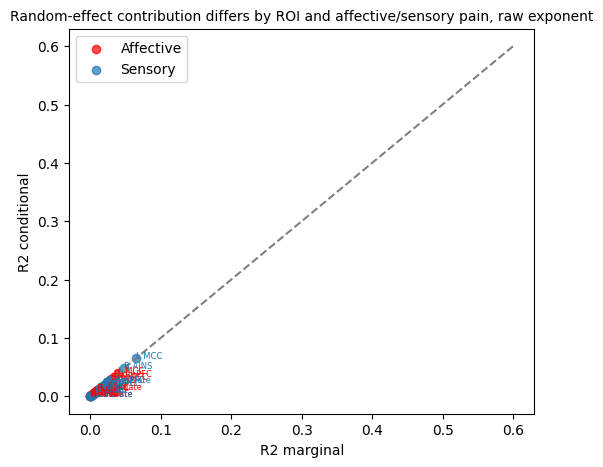

In [70]:
results_df = final_summary
results_df['delta_r2_aff']  = results_df['r2_conditional_aff_raw']  - results_df['r2_marginal_aff_raw']
results_df['delta_r2_sens'] = results_df['r2_conditional_sens_raw'] - results_df['r2_marginal_sens_raw']

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(results_df['delta_r2_aff'], results_df['delta_r2_sens'])
for i, roi in enumerate(results_df['roi']):
    plt.annotate(roi, (results_df['delta_r2_aff'][i], results_df['delta_r2_sens'][i]), fontsize=7)
plt.plot([0,0.6],[0,0.6],'--',color='gray')
plt.xlabel('Δ R2 (conditional - marginal), raw exponent ~ affective')
plt.ylabel('Δ R2 (conditional - marginal), raw exponent ~ sensory')
plt.title('Random effect on patients affect ROIs differently in affective and sensory pain, raw exponent', fontsize=10)
# plt.close()

plt.figure(figsize=(6,5))
plt.scatter(results_df['r2_marginal_aff_raw'], results_df['r2_conditional_aff_raw'], label='Affective', alpha=0.7,color='red')
plt.scatter(results_df['r2_marginal_sens_raw'], results_df['r2_conditional_sens_raw'], label='Sensory', alpha=0.7,color='C0')
for i, roi in enumerate(results_df['roi']):
    plt.annotate(roi, (results_df['r2_marginal_aff_raw'][i], results_df['r2_conditional_aff_raw'][i]), fontsize=6, color='red')
    plt.annotate(roi, (results_df['r2_marginal_sens_raw'][i], results_df['r2_conditional_sens_raw'][i]), fontsize=6, color='C0')
plt.plot([0,0.6],[0,0.6],'--',color='gray')
plt.xlabel('R2 marginal')
plt.ylabel('R2 conditional')
plt.legend()
plt.title('Random-effect contribution differs by ROI and affective/sensory pain, raw exponent',fontsize=10)

In [ ]:
df = all_records_pd
for roi in ['L MCC', 'L OFC', 'L dmPFC']:
    records_kept = df[(df['roi'] == roi) & (df['r2']>=0.9)]
    print(f"\n=== {roi} ===")
    summary = records_kept.groupby('ptID').agg(
        n=('exponent','size'),
        exp_mean=('exponent','mean'), exp_std=('exponent','std'),
        aff_std=('affective','std'), sens_std=('sensory','std')
    )
    print(summary)

In [ ]:
results_df['delta_r2_aff_z']  = results_df['r2_conditional_aff_z']  - results_df['r2_marginal_aff_z']
results_df['delta_r2_sens_z'] = results_df['r2_conditional_sens_z'] - results_df['r2_marginal_sens_z']

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(results_df['delta_r2_aff_z'], results_df['delta_r2_sens_z'])
for i, roi in enumerate(results_df['roi']):
    plt.annotate(roi, (results_df['delta_r2_aff_z'][i], results_df['delta_r2_sens_z'][i]), fontsize=7)
plt.plot([0,0.6],[0,0.6],'--',color='gray')
plt.xlabel('Δ R2 (conditional - marginal), exponent_z ~ affective')
plt.ylabel('Δ R2 (conditional - marginal), exponent_z ~ sensory')
plt.title('Random effect on patients affect ROIs differently in affective and sensory pain, exponent_z', fontsize=10)
# plt.close()

plt.figure(figsize=(6,5))
plt.scatter(results_df['r2_marginal_aff_z'], results_df['r2_conditional_aff_z'], label='Affective', alpha=0.7,color='red')
plt.scatter(results_df['r2_marginal_sens_z'], results_df['r2_conditional_sens_z'], label='Sensory', alpha=0.7,color='C0')
for i, roi in enumerate(results_df['roi']):
    plt.annotate(roi, (results_df['r2_marginal_aff_z'][i], results_df['r2_conditional_aff_z'][i]), fontsize=6, color='red')
    plt.annotate(roi, (results_df['r2_marginal_sens_z'][i], results_df['r2_conditional_sens_z'][i]), fontsize=6, color='C0')
plt.plot([0,0.6],[0,0.6],'--',color='gray')
plt.xlabel('R2 marginal')
plt.ylabel('R2 conditional')
plt.legend()
plt.title('Random-effect contribution differs by ROI and affective/sensory pain, exponent_z',fontsize=10)

In [ ]:
final_summary.to_csv('/home/jiahuang/test-code-hazel/072026UPDATED_summary_of_exponent_glm_allroi.csv')

In [71]:
beta_summary = results_df[[
    'roi', 
    'beta_sensory_z', 'p_sensory_z_fdr',
    'beta_affect_z', 'p_affect_z_fdr'
]].copy()

beta_summary['sig_sens'] = beta_summary['p_sensory_z_fdr'] < 0.05
beta_summary['sig_aff']  = beta_summary['p_affect_z_fdr'] < 0.05

beta_summary

,roi,beta_sensory_z,p_sensory_z_fdr,beta_affect_z,p_affect_z_fdr,sig_sens,sig_aff
0,L ACC,0.149942,0.018496,0.087825,0.104344,True,False
1,L AINS,0.043417,0.309552,0.047224,0.150272,False,False
2,L Caudate,0.009830,0.860893,0.023248,0.483086,False,False
3,L IC,0.063654,0.055636,0.065106,0.009197,False,True
4,L MCC,0.240771,0.0,0.151338,0.000092,True,True
5,L OFC,-0.127741,0.00294,-0.062523,0.013446,True,True
6,L PINS,0.101642,0.017275,0.111826,0.00113,True,True
7,L THAL,0.103831,0.00425,0.072475,0.007327,True,True
8,L dlPFC,0.215896,0.0,0.118203,0.000168,True,True
9,L dmPFC,0.146609,0.004448,0.147180,0.000455,True,True


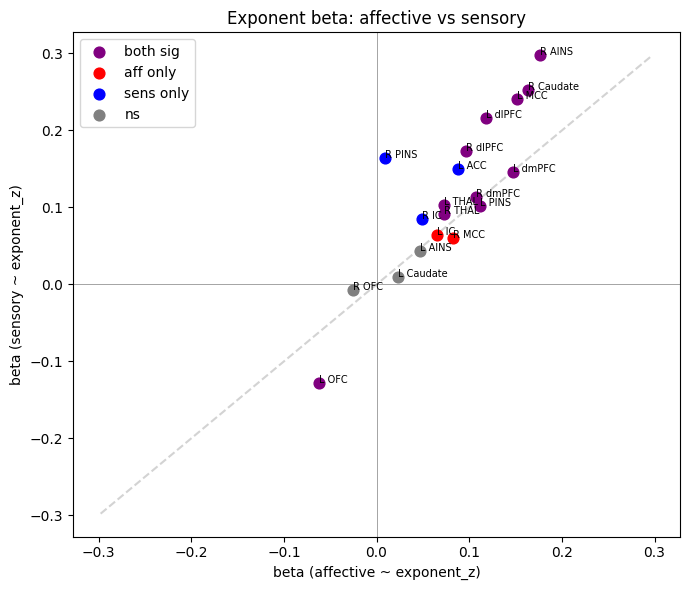

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))

sig_both = beta_summary['sig_aff'] & beta_summary['sig_sens']
sig_aff_only = beta_summary['sig_aff'] & ~beta_summary['sig_sens']
sig_sens_only = ~beta_summary['sig_aff'] & beta_summary['sig_sens']
sig_none = ~beta_summary['sig_aff'] & ~beta_summary['sig_sens']

for mask, color, label in [(sig_both,'purple','both sig'), (sig_aff_only,'red','aff only'),
                            (sig_sens_only,'blue','sens only'), (sig_none,'gray','ns')]:
    ax.scatter(beta_summary.loc[mask,'beta_affect_z'], beta_summary.loc[mask,'beta_sensory_z'],
               color=color, label=label, s=60)

for i, roi in enumerate(beta_summary['roi']):
    ax.annotate(roi, (beta_summary['beta_affect_z'][i], beta_summary['beta_sensory_z'][i]), fontsize=7)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
lims = max(beta_summary[['beta_affect_z','beta_sensory_z']].abs().max())
ax.plot([-lims,lims],[-lims,lims], '--', color='lightgray', zorder=0)
ax.set_xlabel('beta (affective ~ exponent_z)')
ax.set_ylabel('beta (sensory ~ exponent_z)')
ax.legend()
ax.set_title('Exponent beta: affective vs sensory')
plt.tight_layout()

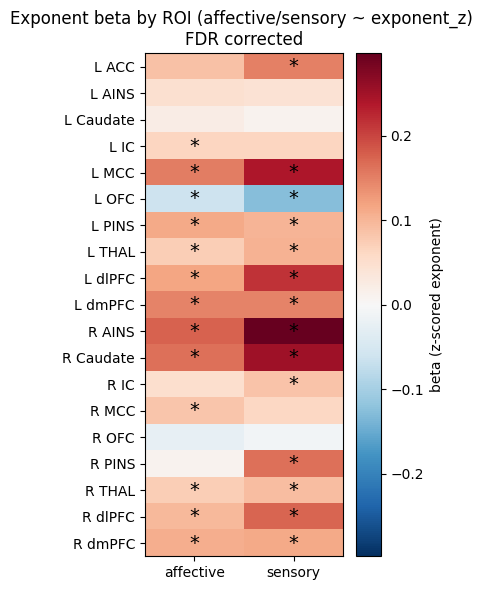

In [75]:
fig, ax = plt.subplots(figsize=(4, 6))
roi_order = beta_summary.sort_values('roi')['roi']
heat_data = beta_summary.set_index('roi').loc[roi_order, ['beta_affect_z','beta_sensory_z']]

im = ax.imshow(heat_data.values, cmap='RdBu_r', aspect='auto', 
               vmin=-np.abs(heat_data.values).max(), vmax=np.abs(heat_data.values).max())
ax.set_yticks(range(len(roi_order)))
ax.set_yticklabels(roi_order)
ax.set_xticks([0,1])
ax.set_xticklabels(['affective','sensory'])

for i, roi in enumerate(roi_order):
    for j, col in enumerate(['sig_aff','sig_sens']):
        if beta_summary.set_index('roi').loc[roi, col]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontsize=14)

fig.colorbar(im, label='beta (z-scored exponent)')
ax.set_title('Exponent beta by ROI (affective/sensory ~ exponent_z) \nFDR corrected')
plt.tight_layout()

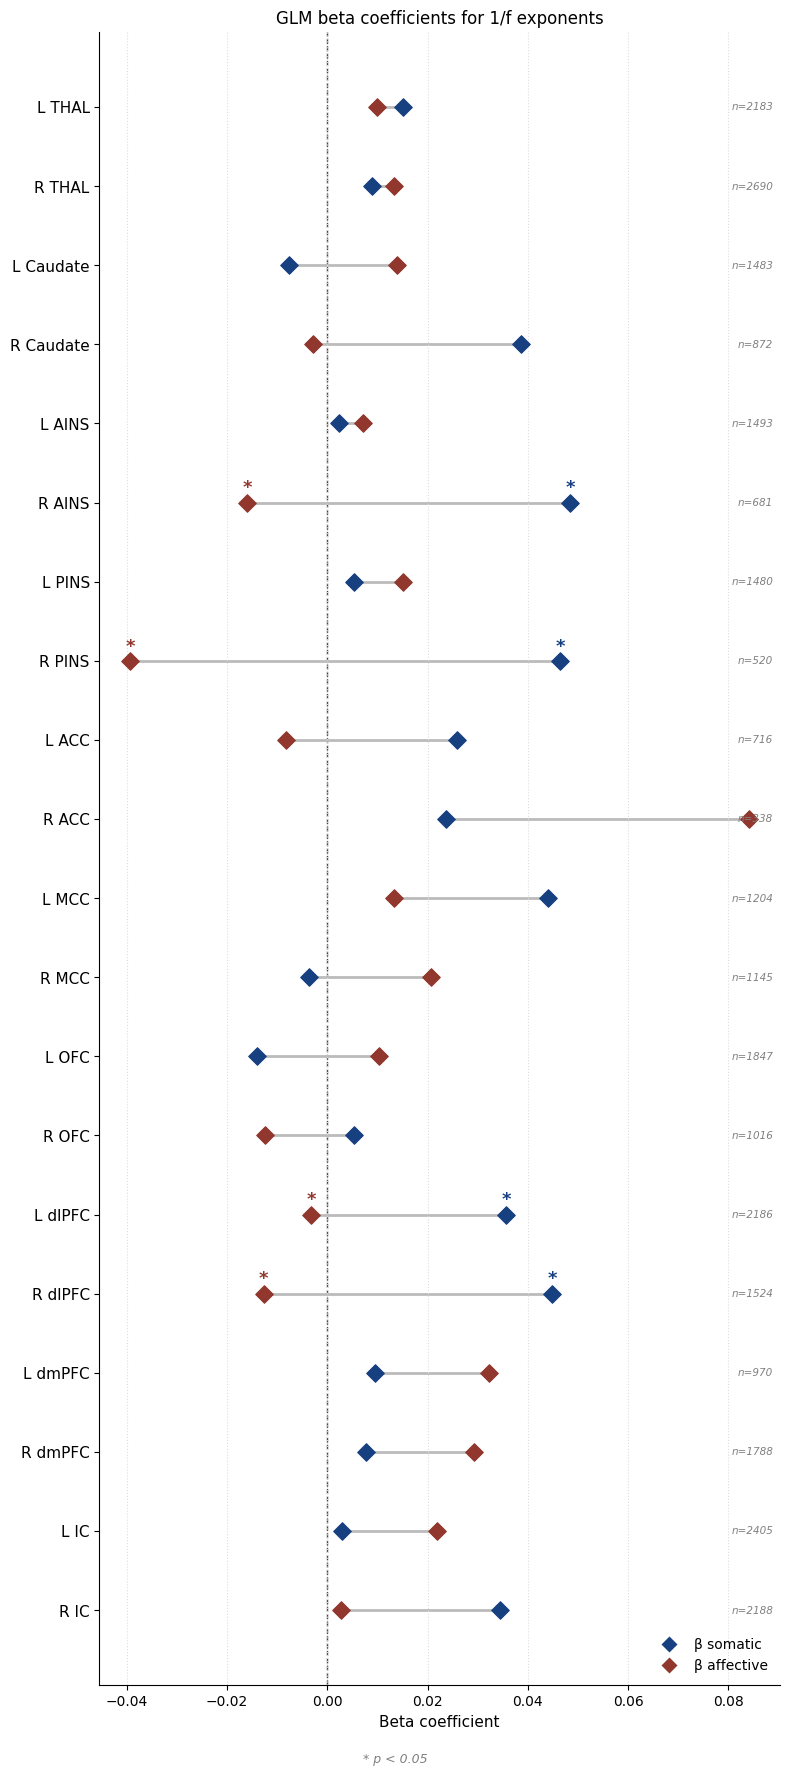

In [20]:
from matplotlib.lines import Line2D

SOM_COLOR    = '#174081'
AFF_COLOR    = '#91372D'

rois = roi_order
y    = np.arange(len(rois))

fig, ax = plt.subplots(figsize=(8, 0.75 * len(rois) + 2.5))

for i, row in results_df.iterrows():
    ax.plot([row['beta_sensory(both)'], row['beta_affect(both)']],
            [y[i], y[i]],
            color='#bbb', linewidth=2.0, zorder=1, alpha=1.0)

    for beta, p, color in [
        (row['beta_sensory(both)'], row['p_difference_both'], SOM_COLOR),
        (row['beta_affect(both)'], row['p_difference_both'], AFF_COLOR),
    ]:
        ax.scatter(beta, y[i], s=80, color=color, zorder=3, marker='D',
                   alpha=1.0, edgecolors=color, linewidths=0.8)
        if p < 0.05:
            ax.text(beta, y[i] - 0.3, '*', ha='center', va='top',
                    fontsize=13, color=color, fontweight='bold')

    ax.text(0.99, y[i], f'n={row["n"]}',
            transform=ax.get_yaxis_transform(),
            va='center', ha='right', fontsize=7.5,
            color='gray', style='italic')

ax.axvline(0, color='#444', linestyle='--', linewidth=1, zorder=0)
ax.set_yticks(y)
ax.set_yticklabels(rois, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Beta coefficient', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle=':', color='#ddd', zorder=0)

handles = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor=SOM_COLOR,
           markersize=9, label='β somatic'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=AFF_COLOR,
           markersize=9, label='β affective'),
]
ax.legend(handles=handles, frameon=False, fontsize=10, loc='lower right')

fig.text(0.5, -0.01, '* p < 0.05',
         ha='center', fontsize=9, color='gray', style='italic')
plt.title("GLM beta coefficients for 1/f exponents")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 0.6*len(results_df)+1))

y_pos = np.arange(len(results_df))

offset = 0.15

for i, row in results_df.iterrows():
    ax.plot([row['ci_sens_lo'], row['ci_sens_hi']], [i+offset, i+offset], 
             color='#174081', lw=2)
    ax.scatter(row['beta_sensory'], i+offset, color='#174081', s=50, zorder=3)
    
    ax.plot([row['ci_aff_lo'], row['ci_aff_hi']], [i-offset, i-offset], 
             color="#91372D", lw=2)
    ax.scatter(row['beta_affect'], i-offset, color='#91372D', s=50, zorder=3)
    
    if row['contrast_p'] < 0.05:
        ax.text(max(row['ci_sens_hi'], row['ci_aff_hi']) + 0.02, i, 
                '*', fontsize=14, color="#000000", va='center', fontweight='bold')
        
    ax.text(1.02, i, f"n={row['n']}", transform=ax.get_yaxis_transform(),
             fontsize=7, va='center', ha='left', color='gray')

ax.axvline(0, color='gray', linestyle='--', lw=1, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['roi'].astype(str))
ax.set_xlabel('Beta coefficient')
ax.set_title('GLM beta coefficients for 1/f exponents (95% CI)')


handles = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor=SOM_COLOR,
           markersize=9, label='β somatic'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=AFF_COLOR,
           markersize=9, label='β affective'),
]
ax.legend(handles=handles, frameon=False, fontsize=10, loc='lower right')

fig.text(0.5, -0.01, '* p < 0.05',
         ha='center', fontsize=9, color='gray', style='italic')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']

rois = sorted(records_df['roi'].unique())
for ptID in ptIDs:
    print(ptID)
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['ptID'] = ptID
    